# Employee Attrition Prediction using Logistic Regression

## Objective
The objective of this project is to predict whether an employee is likely to leave the company based on various factors such as age, income, job role, overtime, and job satisfaction using Logistic Regression.

### Dataset
IBM HR Analytics Employee Attrition & Performance Dataset

### Algorithm Used
- Logistic Regression

### Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
# Display first five rows

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Display last five rows

df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [5]:
# Number of rows and columns

df.shape

(1470, 35)

In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
# Summary statistics

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
# Display all column names

df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
# Check missing values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Count employees who stayed and left

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

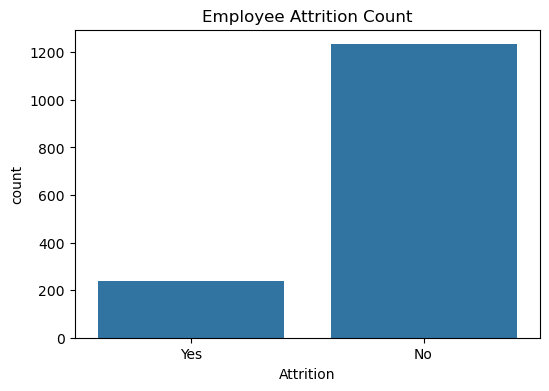

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Count")

plt.savefig("images/attrition_count.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

Most employees did not leave the company, while comparatively fewer employees left.

This indicates that the dataset is **imbalanced**, which is common in employee attrition datasets.

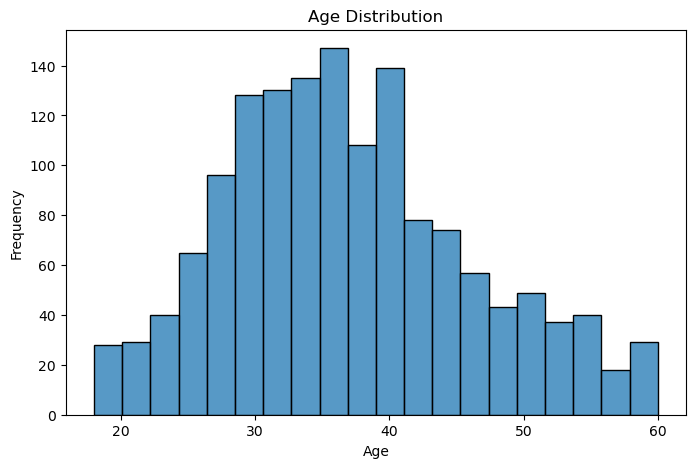

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.savefig("images/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

Most employees are between 30 and 40 years old.

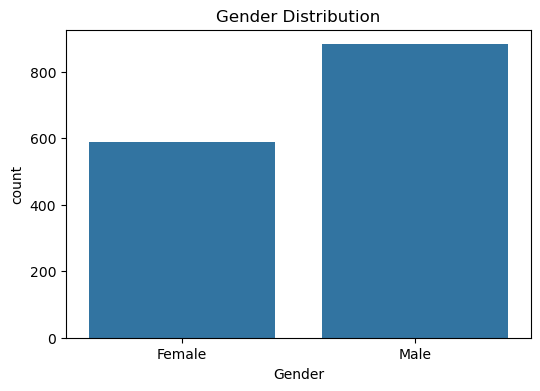

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.savefig("images/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

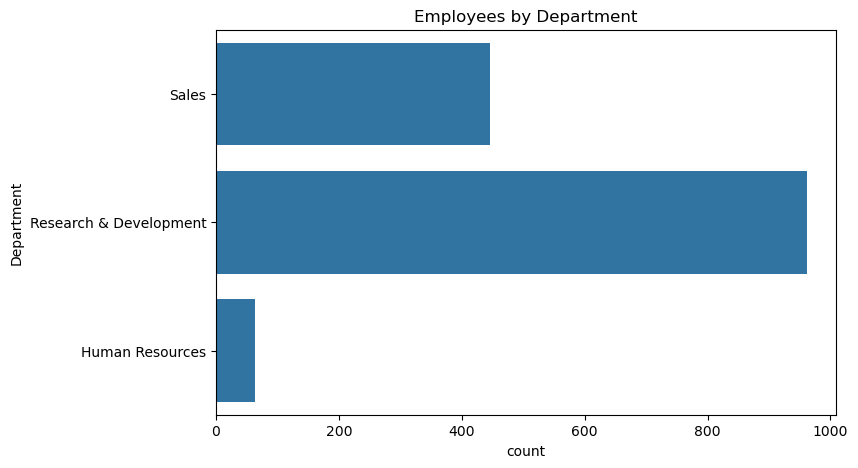

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(y="Department", data=df)

plt.title("Employees by Department")

plt.savefig("images/department_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

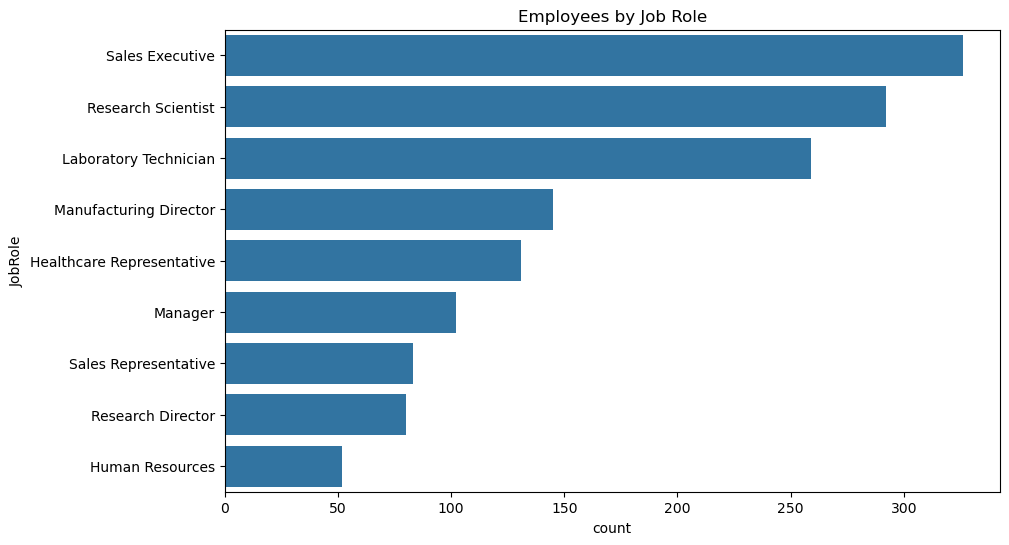

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(y="JobRole", data=df)

plt.title("Employees by Job Role")

plt.savefig("images/job_role_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

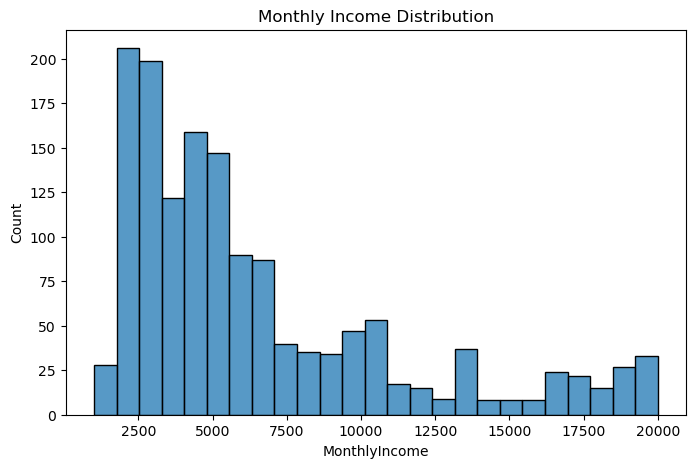

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=25)

plt.title("Monthly Income Distribution")

plt.savefig("images/monthly_income_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

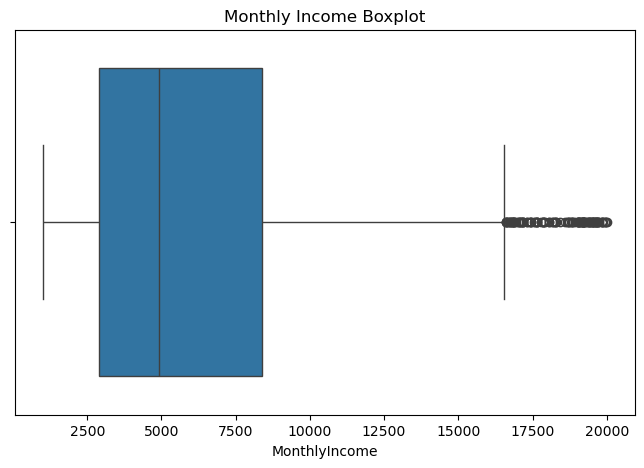

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["MonthlyIncome"])

plt.title("Monthly Income Boxplot")

plt.savefig("images/overtime_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

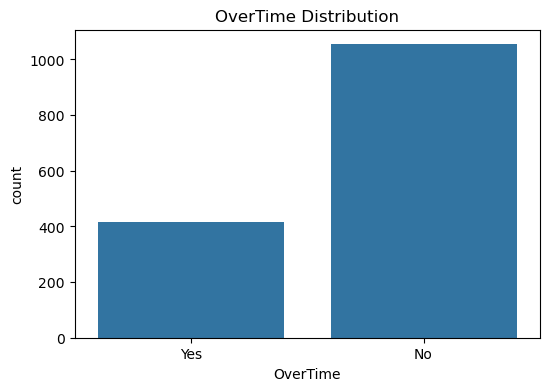

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="OverTime", data=df)

plt.title("OverTime Distribution")

plt.savefig("images/overtime_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

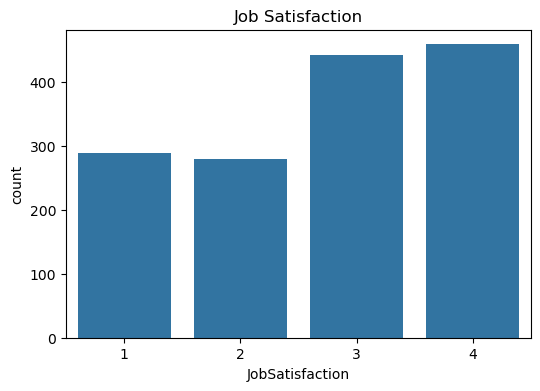

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="JobSatisfaction", data=df)

plt.title("Job Satisfaction")

plt.savefig("images/job_satisfaction.png", dpi=300, bbox_inches="tight")

plt.show()

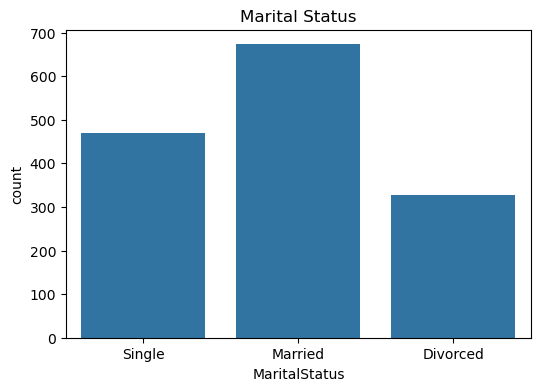

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="MaritalStatus", data=df)

plt.title("Marital Status")

plt.savefig("images/marital_status.png", dpi=300, bbox_inches="tight")

plt.show()

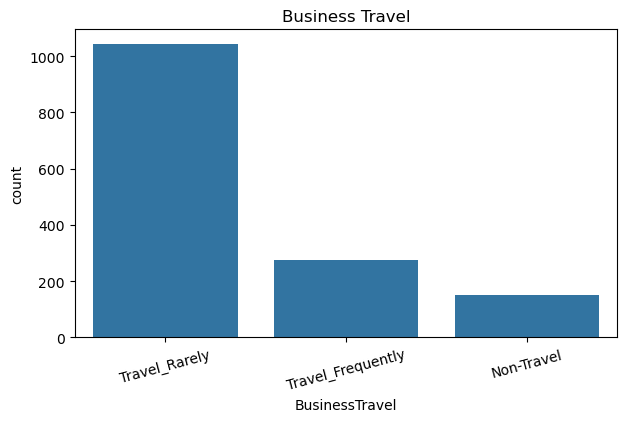

In [22]:
plt.figure(figsize=(7,4))

sns.countplot(x="BusinessTravel", data=df)

plt.title("Business Travel")

plt.xticks(rotation=15)

plt.savefig("images/business_travel.png", dpi=300, bbox_inches="tight")

plt.show()

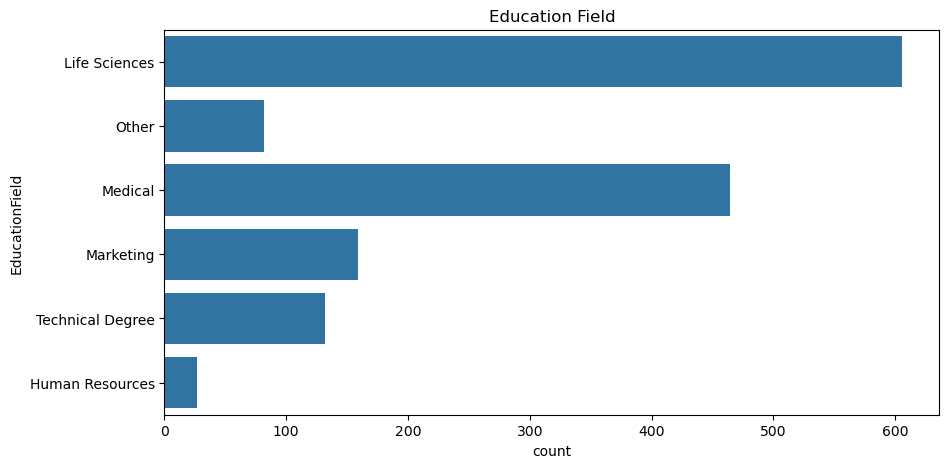

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(y="EducationField", data=df)

plt.title("Education Field")

plt.savefig("images/education_field.png", dpi=300, bbox_inches="tight")

plt.show()

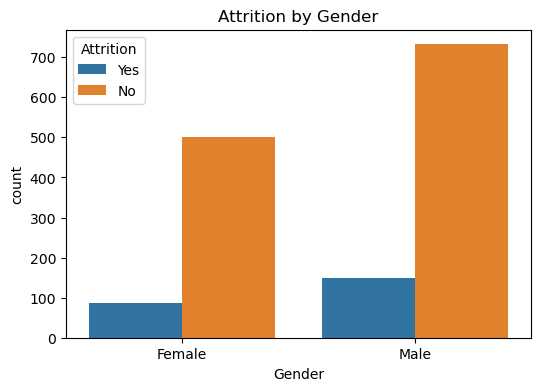

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Attrition", data=df)

plt.title("Attrition by Gender")

plt.savefig("images/attrition_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

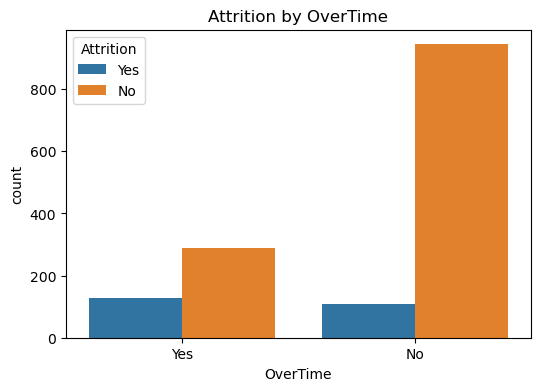

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="OverTime", hue="Attrition", data=df)

plt.title("Attrition by OverTime")

plt.savefig("images/attrition_by_overtime.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

Employees who work overtime appear to leave the company more frequently than employees who do not work overtime.

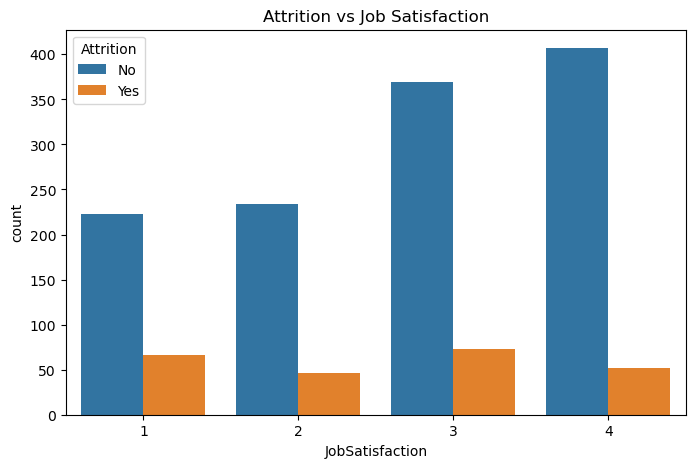

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)

plt.title("Attrition vs Job Satisfaction")

plt.savefig("images/attrition_by_job_satisfaction.png", dpi=300, bbox_inches="tight")

plt.show()

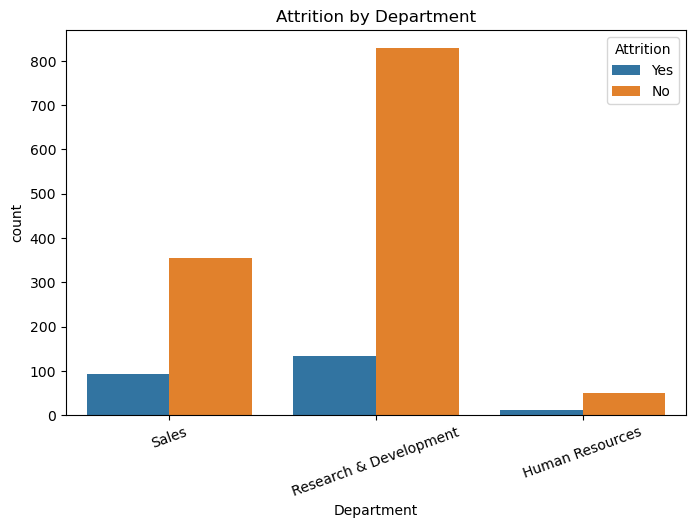

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Attrition by Department")

plt.xticks(rotation=20)

plt.savefig("images/attrition_by_department.png", dpi=300, bbox_inches="tight")

plt.show()

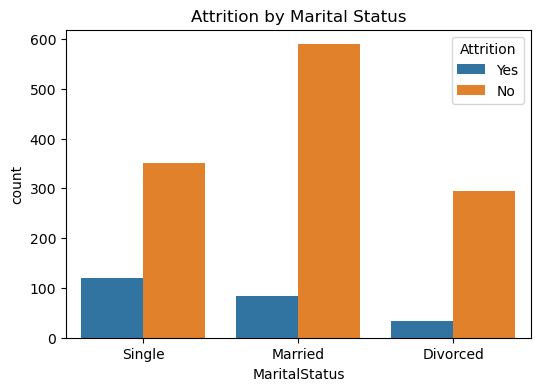

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="MaritalStatus", hue="Attrition", data=df)

plt.title("Attrition by Marital Status")

plt.savefig("images/attrition_by_marital_status.png", dpi=300, bbox_inches="tight")

plt.show()

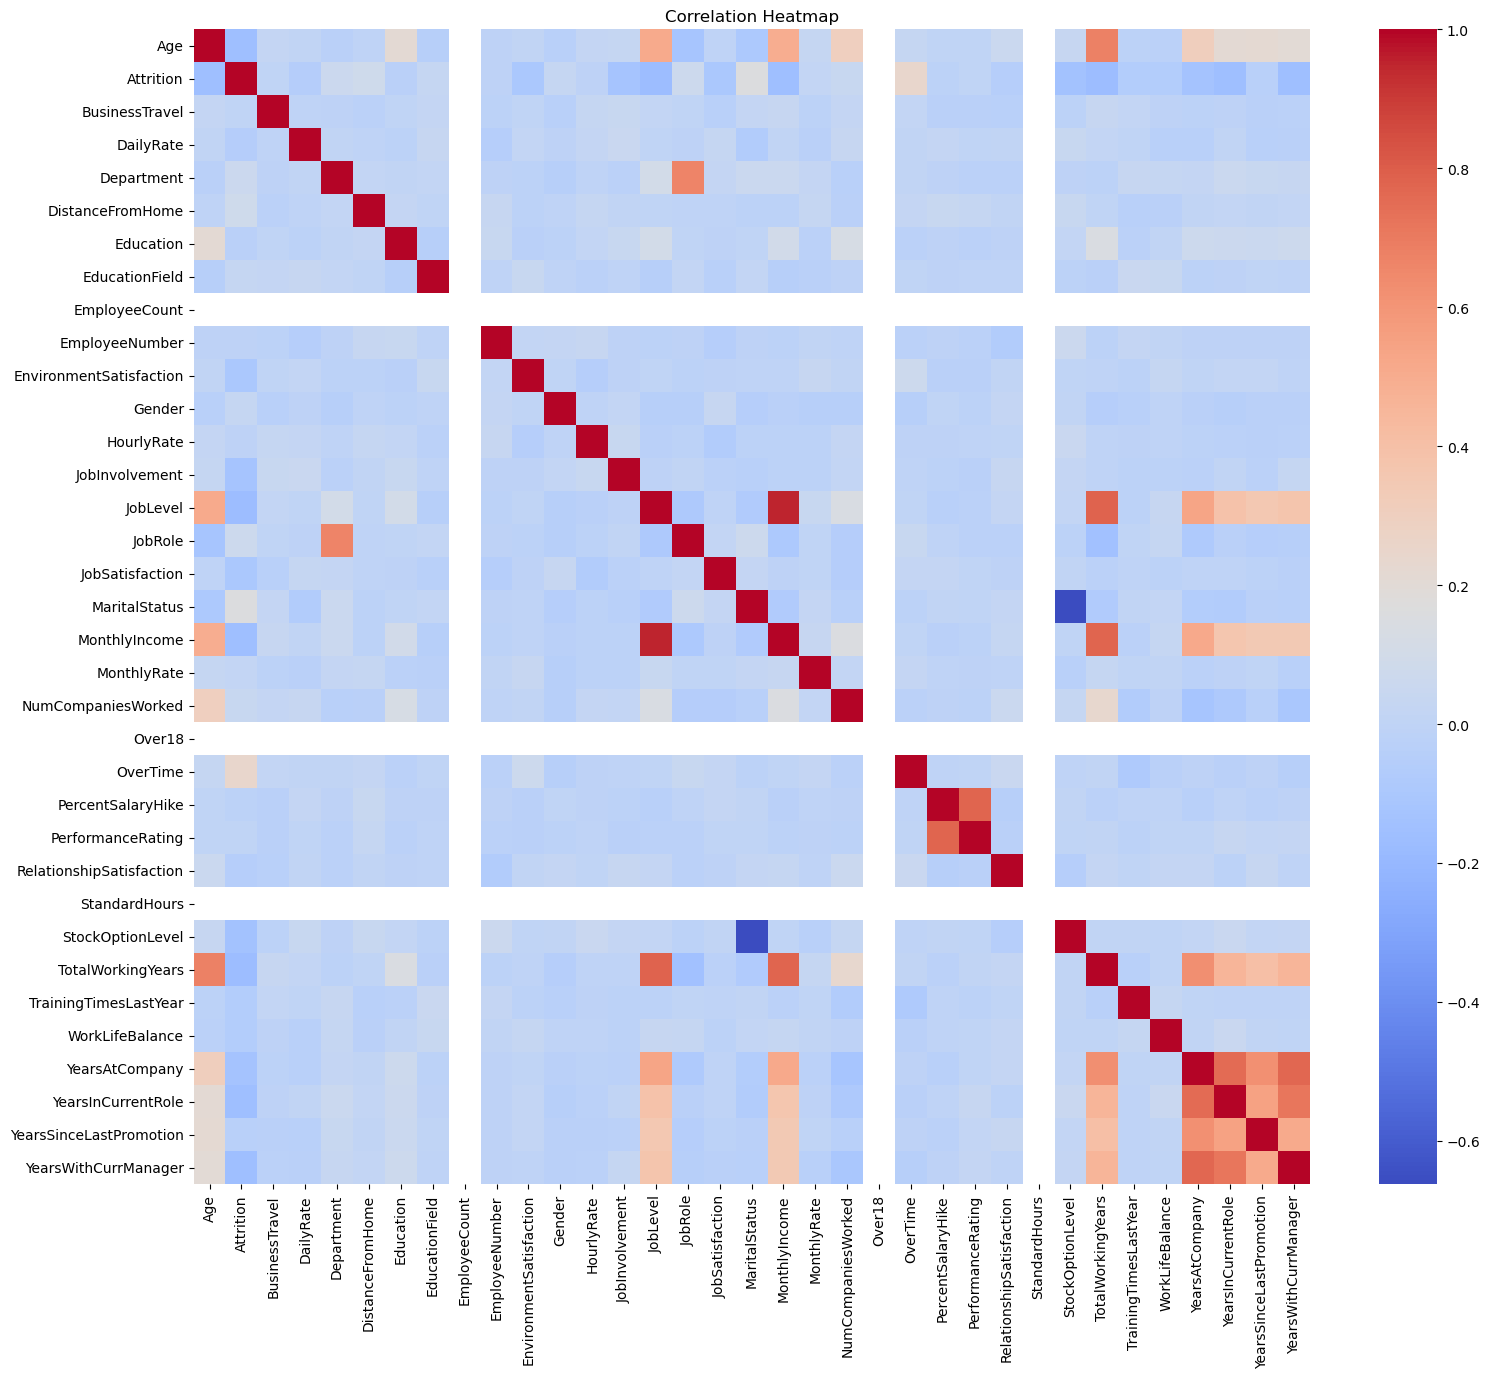

In [29]:
temp = df.copy()

encoder = LabelEncoder()

for column in temp.columns:
    if temp[column].dtype == "object":
        temp[column] = encoder.fit_transform(temp[column])

plt.figure(figsize=(18,15))

sns.heatmap(temp.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

## Summary of EDA

From the exploratory analysis, we observed:

- The dataset contains no missing values.
- The dataset is imbalanced.
- Employees working overtime have a higher attrition rate.
- Monthly income varies significantly among employees.
- Most employees belong to the Research & Development department.
- Job satisfaction appears to influence employee attrition.

In [30]:
# Create a copy of the dataset

data = df.copy()

In [31]:
# Display dataset

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [32]:
# Check missing values

data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

There are no missing values in the dataset.

In [33]:
# Check duplicate rows

data.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found.

In [34]:
# Number of unique values in each column

data.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [35]:
# Drop unnecessary columns (if they exist)

data.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ],
    errors="ignore",
    inplace=True
)

print("Remaining Columns:", len(data.columns))

Remaining Columns: 31


In [36]:
print(data.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [37]:
# Display remaining columns

data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### Why were these columns removed?

- EmployeeNumber is just an ID.
- EmployeeCount has the same value for every employee.
- Over18 contains only "Y".
- StandardHours is constant for every employee.

These columns do not help the machine learning model.

In [38]:
# Display categorical columns

categorical_columns = data.select_dtypes(include="object").columns

categorical_columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [39]:
# Encode categorical variables

encoder = LabelEncoder()

for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])

print("Encoding Completed Successfully")

Encoding Completed Successfully


In [40]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [41]:
data.dtypes

Age                         int64
Attrition                   int64
BusinessTravel              int64
DailyRate                   int64
Department                  int64
DistanceFromHome            int64
Education                   int64
EducationField              int64
EnvironmentSatisfaction     int64
Gender                      int64
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int64
JobSatisfaction             int64
MaritalStatus               int64
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
OverTime                    int64
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLast

### Observation

All categorical columns have now been converted into numerical values.

In [42]:
# Independent variables

X = data.drop("Attrition", axis=1)

# Target variable

y = data["Attrition"]

In [43]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1470, 30)
Target Shape : (1470,)


In [44]:
X.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (1176, 30)
Testing Features : (294, 30)
Training Labels : (1176,)
Testing Labels : (294,)


### Observation

80% of the data is used for training while 20% is used for testing.

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [50]:
X_train = scaler.fit_transform(X_train)

In [51]:
X_test = scaler.transform(X_test)

In [52]:
X_train

array([[ 1.09019402,  0.59751994,  1.04945488, ..., -0.62536487,
        -0.36802436, -0.6164065 ],
       [-1.6348276 ,  0.59751994, -0.52344929, ..., -0.9056351 ,
        -0.05688371, -0.89704685],
       [ 0.98119316,  0.59751994, -0.99208001, ...,  1.33652675,
         0.5653976 ,  1.348076  ],
       ...,
       [-1.6348276 ,  0.59751994, -1.46320345, ..., -0.34509464,
        -0.36802436, -0.89704685],
       [-0.10881549,  0.59751994, -0.93225481, ..., -1.18590534,
        -0.67916501, -1.17768721],
       [ 0.21818711, -0.89437699, -0.09470203, ..., -0.9056351 ,
        -0.05688371, -0.6164065 ]], shape=(1176, 30))

In [53]:
X_test

array([[-1.41682587e+00, -2.38627392e+00,  6.48318281e-02, ...,
        -1.18590534e+00, -6.79165010e-01, -1.17768721e+00],
       [ 7.63191429e-01,  5.97519945e-01,  7.80241491e-01, ...,
         2.15445825e-01,  1.49881955e+00,  7.86795286e-01],
       [-6.53819813e-01,  5.97519945e-01, -2.89133929e-01, ...,
        -6.48244074e-02, -6.79165010e-01, -8.97046855e-01],
       ...,
       [-1.08815489e-01,  5.97519945e-01,  1.62527242e+00, ...,
        -6.25364871e-01, -5.68837075e-02, -6.16406498e-01],
       [ 2.07120181e+00,  5.97519945e-01,  1.12423638e+00, ...,
        -6.25364871e-01, -3.68024359e-01, -1.17768721e+00],
       [ 1.85375620e-04,  5.97519945e-01,  1.41588422e+00, ...,
         2.17733745e+00,  8.76538246e-01,  7.86795286e-01]],
      shape=(294, 30))

### Why StandardScaler?

StandardScaler converts every feature into a common scale with:

- Mean = 0
- Standard Deviation = 1

This helps Logistic Regression converge faster and prevents features with larger values from dominating the model.

In [54]:
y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

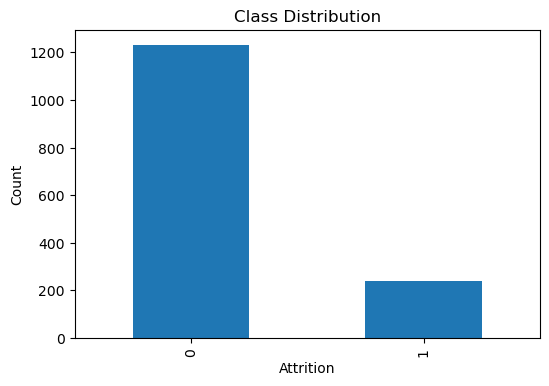

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

y.value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

### Observation

The dataset is imbalanced because the number of employees who stayed is much higher than those who left.

This can affect the model's ability to correctly identify employees likely to leave.

Common methods to handle class imbalance:

1. Oversampling (Random Oversampling)
2. SMOTE (Synthetic Minority Oversampling Technique)
3. Undersampling
4. Using class_weight='balanced' in Logistic Regression

For this project, we will use the **class_weight='balanced'** parameter while training the Logistic Regression model. This approach helps the model give more importance to the minority class without changing the dataset.

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

In [57]:
# Create and train the model

model = LogisticRegression(class_weight='balanced', random_state=42)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
# Predict labels

y_pred = model.predict(X_test)

# Predict probabilities

y_prob = model.predict_proba(X_test)[:,1]

In [59]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 75.17 %


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



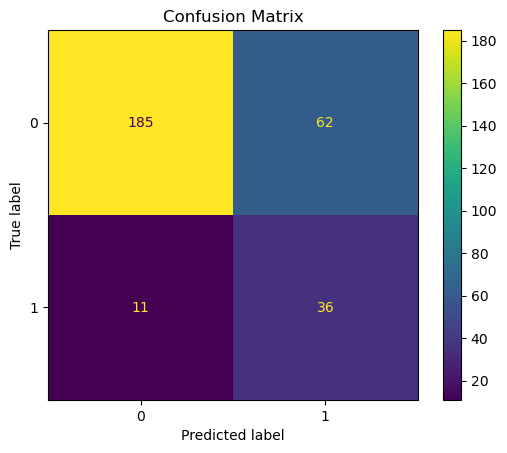

In [61]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

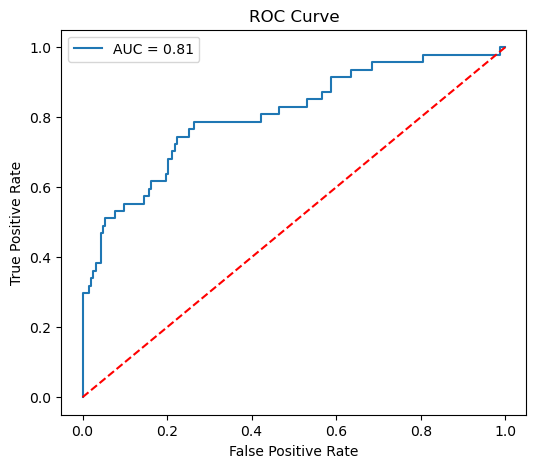

ROC-AUC Score : 0.807


In [62]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

print("ROC-AUC Score :", round(auc,3))

In [63]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

importance.head(10)

,Feature,Coefficient
18,OverTime,0.713114
3,Department,0.490580
28,YearsSinceLastPromotion,0.465691
17,NumCompaniesWorked,0.431994
26,YearsAtCompany,0.320837
14,MaritalStatus,0.301020
4,DistanceFromHome,0.290906
20,PerformanceRating,0.149605
8,Gender,0.142069
11,JobLevel,0.087681


## Conclusion

- Built a Logistic Regression model to predict employee attrition.
- Used StandardScaler for feature scaling.
- Applied `class_weight='balanced'` to handle class imbalance.
- Evaluated the model using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC.
- The model can help identify employees who are more likely to leave the company.

In [64]:
import os
import matplotlib.pyplot as plt

# Create images folder
os.makedirs("images", exist_ok=True)

# Save all open figures
for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(
        f"images/figure_{fig_num}.png",
        dpi=300,
        bbox_inches="tight"
    )

print(f"Saved {len(plt.get_fignums())} images in the 'images' folder.")

Saved 0 images in the 'images' folder.
